# Histogram bins comparison for STAGE

In [2]:
from scipy.stats import skew, kurtosis
from helper_files.feature_selection_helper import *

main_folder_path = r"E:\DATA_Myelomy"

all_shape_values = {}
for folder_name in os.listdir(main_folder_path):
    patient_folder = os.path.join(main_folder_path, folder_name)
    csv_files = glob.glob(os.path.join(patient_folder, "*individual_lesion_features*.csv"))

    df = pd.read_csv(csv_files[0]).filter(like="shape")
    for col in df.columns:
        all_shape_values.setdefault(col, []).extend(df[col].dropna().values)

global_ranges = {col: (np.min(vals), np.max(vals)) for col, vals in all_shape_values.items()}

N_BINS = 20
global_bins = {col: np.linspace(vmin, vmax, N_BINS + 1) for col, (vmin, vmax) in global_ranges.items()}

all_patients = []
for folder_name in os.listdir(main_folder_path):
    patient_folder = os.path.join(main_folder_path, folder_name)
    csv_files = glob.glob(os.path.join(patient_folder, "*individual_lesion_features*.csv"))

    df = pd.read_csv(csv_files[0]).filter(like="shape")
    patient_features = {"patient_id": folder_name}
    for col in df.columns:
        x = df[col].dropna().values

        # ===== distribution statistics =====
        patient_features[f"{col}_skewness"] = skew(x)
        patient_features[f"{col}_kurtosis"] = kurtosis(x)

        patient_features[f"{col}_P10"] = np.quantile(x, 0.10)
        patient_features[f"{col}_P25"] = np.quantile(x, 0.25)
        patient_features[f"{col}_P75"] = np.quantile(x, 0.75)
        patient_features[f"{col}_P90"] = np.quantile(x, 0.90)
        patient_features[f"{col}_IQR"] = np.quantile(x, 0.75) - np.quantile(x, 0.25)

        # ===== HISTOGRAM BINS AS FEATURES =====
        bins = global_bins[col]
        hist, _ = np.histogram(x, bins=bins)
        hist = hist / hist.sum()

        for i, h in enumerate(hist):
            patient_features[f"{col}_hist_bin_{i:02d}"] = h

    all_patients.append(patient_features)
df_final = pd.DataFrame(all_patients)

clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

data = pd.merge(df_final, clinical_df[['Patient ID', 'Stage']], left_on='patient_id', right_on='Patient ID')
numeric_features = df_final.select_dtypes(include='number').columns

results = []
for feature in numeric_features:
    stage1 = data.loc[data['Stage'] == 1, feature].dropna()
    stage2 = data.loc[data['Stage'] == 2, feature].dropna()
    stage3 = data.loc[data['Stage'] == 3, feature].dropna()

    H, p = kruskal(stage1, stage2, stage3)
    results.append({"Feature": feature, "H_statistic": H, "p_value": p})

results_df = (pd.DataFrame(results).sort_values("p_value").reset_index(drop=True))
results_df.head()

,Feature,H_statistic,p_value
0,original_shape_Flatness_hist_bin_12,13.810049,0.001003
1,original_shape_Flatness_P75,13.662323,0.001080
2,original_shape_LeastAxisLength_hist_bin_02,11.777836,0.002770
3,original_shape_Elongation_P25,10.925294,0.004242
4,original_shape_Flatness_hist_bin_09,10.083859,0.006461


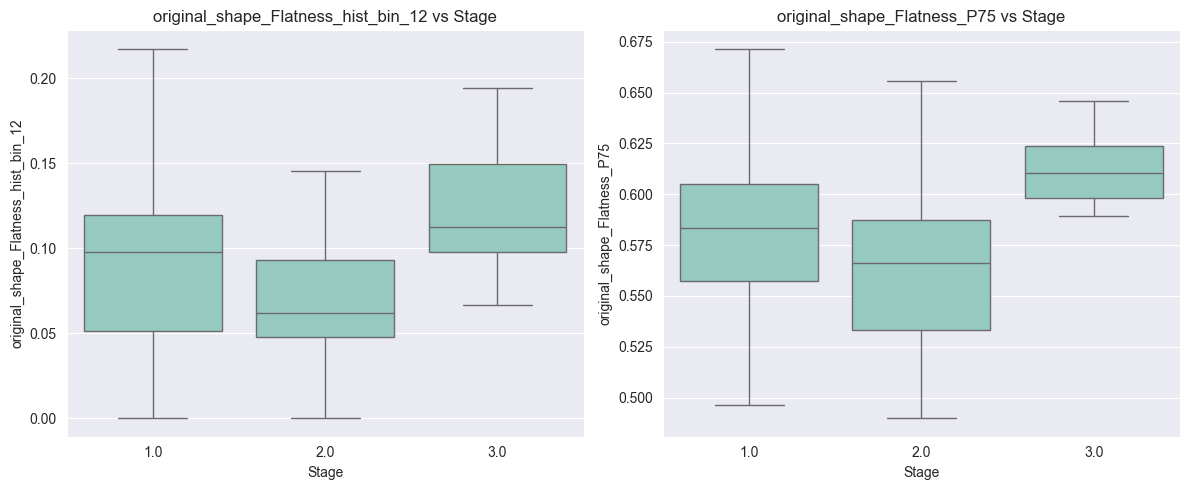

In [4]:
img_feature1 = "original_shape_Flatness_hist_bin_12"
img_feature2 = "original_shape_Flatness_P75"

plt.figure(figsize=(12, 5))

plt.subplot(121)
sns.set_style("darkgrid")
sns.boxplot(x='Stage', y=img_feature1, data=data, showfliers=False)
plt.xlabel('Stage')
plt.ylabel(img_feature1)
plt.title(f'{img_feature1} vs Stage', fontsize=12)

plt.subplot(122)
sns.set_style("darkgrid")
sns.boxplot(x='Stage', y=img_feature2, data=data, showfliers=False)
plt.xlabel('Stage')
plt.ylabel(img_feature2)
plt.title(f'{img_feature2} vs Stage', fontsize=12)

plt.tight_layout()
plt.show()

# Histogram bins comparison for M-PROTEIN TYPE

In [5]:
from scipy.stats import skew, kurtosis
from helper_files.feature_selection_helper import *

main_folder_path = r"E:\DATA_Myelomy"

all_shape_values = {}
for folder_name in os.listdir(main_folder_path):
    patient_folder = os.path.join(main_folder_path, folder_name)
    csv_files = glob.glob(os.path.join(patient_folder, "*individual_lesion_features*.csv"))

    df = pd.read_csv(csv_files[0]).filter(like="shape")
    for col in df.columns:
        all_shape_values.setdefault(col, []).extend(df[col].dropna().values)

global_ranges = {col: (np.min(vals), np.max(vals)) for col, vals in all_shape_values.items()}

N_BINS = 20
global_bins = {col: np.linspace(vmin, vmax, N_BINS + 1) for col, (vmin, vmax) in global_ranges.items()}

all_patients = []
for folder_name in os.listdir(main_folder_path):
    patient_folder = os.path.join(main_folder_path, folder_name)
    csv_files = glob.glob(os.path.join(patient_folder, "*individual_lesion_features*.csv"))

    df = pd.read_csv(csv_files[0]).filter(like="shape")
    patient_features = {"patient_id": folder_name}
    for col in df.columns:
        x = df[col].dropna().values

        # ===== distribution statistics =====
        patient_features[f"{col}_skewness"] = skew(x)
        patient_features[f"{col}_kurtosis"] = kurtosis(x)

        patient_features[f"{col}_P10"] = np.quantile(x, 0.10)
        patient_features[f"{col}_P25"] = np.quantile(x, 0.25)
        patient_features[f"{col}_P75"] = np.quantile(x, 0.75)
        patient_features[f"{col}_P90"] = np.quantile(x, 0.90)
        patient_features[f"{col}_IQR"] = np.quantile(x, 0.75) - np.quantile(x, 0.25)

        # ===== HISTOGRAM BINS AS FEATURES =====
        bins = global_bins[col]
        hist, _ = np.histogram(x, bins=bins)
        hist = hist / hist.sum()

        for i, h in enumerate(hist):
            patient_features[f"{col}_hist_bin_{i:02d}"] = h

    all_patients.append(patient_features)
df_final = pd.DataFrame(all_patients)

clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

data = pd.merge(df_final, clinical_df[['Patient ID', 'M-protein type']], left_on='patient_id', right_on='Patient ID')
numeric_features = df_final.select_dtypes(include='number').columns

results = []
for feature in numeric_features:
    stage1 = data.loc[data['M-protein type'] == "IgA", feature].dropna()
    stage2 = data.loc[data['M-protein type'] == "IgG", feature].dropna()
    stage3 = data.loc[data['M-protein type'] == "LC only", feature].dropna()

    H, p = kruskal(stage1, stage2, stage3)
    results.append({"Feature": feature, "H_statistic": H, "p_value": p})

results_df = (pd.DataFrame(results).sort_values("p_value").reset_index(drop=True))
results_df.head()

,Feature,H_statistic,p_value
0,original_shape_Maximum2DDiameterColumn_hist_bi...,12.932997,0.001555
1,original_shape_Maximum3DDiameter_hist_bin_16,10.140845,0.006280
2,original_shape_Sphericity_hist_bin_16,10.064204,0.006525
3,original_shape_MajorAxisLength_hist_bin_10,9.947079,0.006919
4,original_shape_SurfaceVolumeRatio_P10,9.216296,0.009970


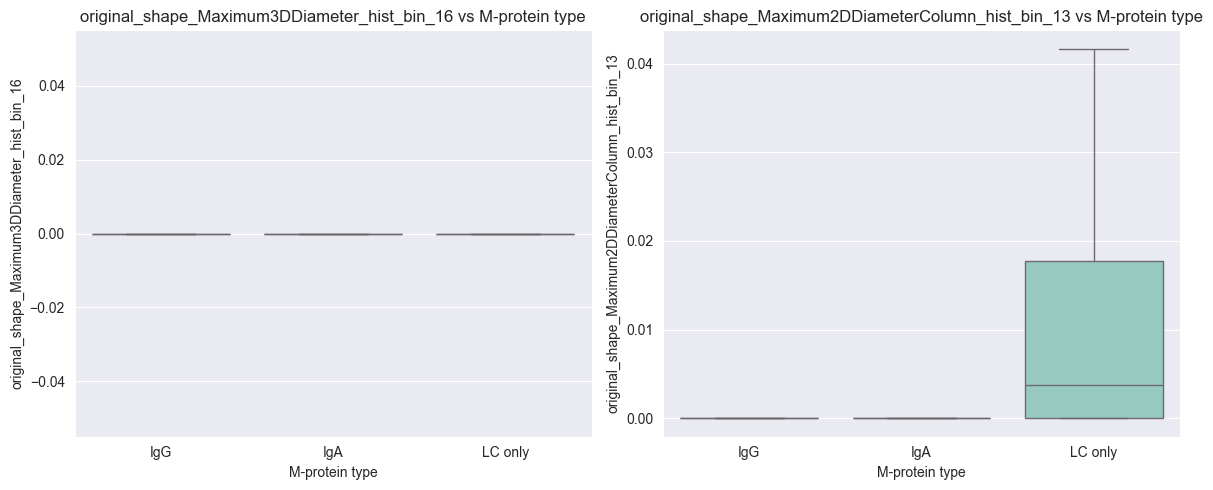

In [6]:
img_feature1 = "original_shape_Maximum3DDiameter_hist_bin_16"
img_feature2 = "original_shape_Maximum2DDiameterColumn_hist_bin_13"

plt.figure(figsize=(12, 5))

plt.subplot(121)
sns.set_style("darkgrid")
sns.boxplot(x='M-protein type', y=img_feature1, data=data, showfliers=False)
plt.xlabel('M-protein type')
plt.ylabel(img_feature1)
plt.title(f'{img_feature1} vs M-protein type', fontsize=12)

plt.subplot(122)
sns.set_style("darkgrid")
sns.boxplot(x='M-protein type', y=img_feature2, data=data, showfliers=False)
plt.xlabel('M-protein type')
plt.ylabel(img_feature2)
plt.title(f'{img_feature2} vs M-protein type', fontsize=12)

plt.tight_layout()
plt.show()